In [1]:
import requests 
from bs4 import BeautifulSoup

In [2]:
result = requests.get("https://keur-immo.com/senegal/")
recup = result.text
data = BeautifulSoup(recup, "html.parser")

In [3]:
annonces = data.find_all("article", class_="g5core__gutter-item")
len(annonces) 

36

In [4]:
text = annonces[0].find("h3", class_="g5ere__loop-property-title").text
print(text)


NGAPAROU : Magnifique Villa à louer



In [5]:
prix = annonces[0].find("span", class_="g5ere__lpp-price").text
print(prix)

800 000 FCFA


In [6]:
chambre = annonces[0].find("span", class_="g5ere__property-bedrooms")
print(chambre)
bain = annonces[0].find("span", class_="g5ere__loop-property-bathrooms")
print(bain)
surface = annonces[0].find("span", class_="g5ere__loop-property-size")
print(surface)

<span class="g5ere__property-bedrooms">3 Ch.</span>
<span class="g5ere__loop-property-bathrooms">3 Sdb</span>
<span class="g5ere__loop-property-size">180 m<sup>2</sup></span>


In [7]:
import pandas as pd
df = pd.read_csv("nigeria_houses_data.csv")
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


In [8]:
df.info

<bound method DataFrame.info of        bedrooms  bathrooms  toilets  parking_space                 title  \
0           6.0        5.0      5.0            4.0       Detached Duplex   
1           4.0        5.0      5.0            4.0     Terraced Duplexes   
2           4.0        5.0      5.0            4.0       Detached Duplex   
3           4.0        4.0      5.0            6.0       Detached Duplex   
4           4.0        4.0      5.0            2.0  Semi Detached Duplex   
...         ...        ...      ...            ...                   ...   
24321       2.0        2.0      2.0            4.0        Block of Flats   
24322       4.0        5.0      5.0            4.0        Block of Flats   
24323       4.0        5.0      5.0            4.0       Detached Duplex   
24324       3.0        4.0      4.0            3.0        Block of Flats   
24325       4.0        5.0      5.0            4.0       Detached Duplex   

                       town  state        price  
0    

In [9]:
df.isnull().sum()

bedrooms         0
bathrooms        0
toilets          0
parking_space    0
title            0
town             0
state            0
price            0
dtype: int64

In [10]:
df.describe()

,bedrooms,bathrooms,toilets,parking_space,price
count,24326.000000,24326.000000,24326.000000,24326.000000,2.432600e+04
mean,4.338814,4.600798,5.176355,4.041725,3.013802e+08
std,1.138497,1.163161,1.226253,1.399936,1.220403e+10
min,1.000000,1.000000,1.000000,1.000000,9.000000e+04
25%,4.000000,4.000000,5.000000,4.000000,5.200000e+07
50%,4.000000,5.000000,5.000000,4.000000,8.500000e+07
75%,5.000000,5.000000,6.000000,4.000000,1.600000e+08
max,9.000000,9.000000,9.000000,9.000000,1.800000e+12


In [11]:
# 1. Calcul du seuil des 99%
seuil = df['price'].quantile(0.99)
print(f"Le prix limite (quantile 0.99) est de : {seuil:,.2f} NGN")

# 2. Filtrage du DataFrame
df_clean = df[df['price'] < seuil]

# 3. Comparaison du prix moyen
print(f"Ancienne moyenne : {df['price'].mean():,.2f} NGN")
print(f"Nouvelle moyenne nettoyée : {df_clean['price'].mean():,.2f} NGN")

Le prix limite (quantile 0.99) est de : 1,400,000,000.00 NGN
Ancienne moyenne : 301,380,208.47 NGN
Nouvelle moyenne nettoyée : 145,990,331.30 NGN


In [12]:
df_clean.describe()

,bedrooms,bathrooms,toilets,parking_space,price
count,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04
mean,4.325208,4.588750,5.167417,4.037833,1.459903e+08
std,1.124352,1.151454,1.213617,1.392833,1.833203e+08
min,1.000000,1.000000,1.000000,1.000000,9.000000e+04
25%,4.000000,4.000000,5.000000,4.000000,5.000000e+07
50%,4.000000,5.000000,5.000000,4.000000,8.500000e+07
75%,5.000000,5.000000,6.000000,4.000000,1.550000e+08
max,9.000000,9.000000,9.000000,9.000000,1.395000e+09


In [13]:
len(df) - len(df_clean)

326

In [14]:
print(df_clean['town'].unique())
print(df_clean['state'].unique())
print(df_clean['title'].unique())

<StringArray>
[             'Mabushi',              'Katampe',                'Lekki',
                 'Ajah',                  'Epe',    'Lokogoma District',
                'Oredo', 'Victoria Island (VI)',           'Mowe Ofada',
                'Ikeja',
 ...
        'Ughelli South',              'Ewekoro',            'Nassarawa',
             'Mararaba',           'Uhunmwonde',        'Ughelli North',
                'Ibeju',               'Abraka',              'Paikoro',
          'Ikpoba Okha']
Length: 189, dtype: str
<StringArray>
[      'Abuja',       'Lagos',         'Edo',        'Ogun',         'Oyo',
         'Imo',    'Anambara',      'Rivers',       'Enugu',      'Kaduna',
       'Kwara',    'Nasarawa',        'Abia',       'Delta',   'Akwa Ibom',
        'Osun',       'Ekiti', 'Cross River',        'Kogi',     'Plateau',
        'Kano',     'Katsina',     'Bayelsa',       'Borno',       'Niger']
Length: 25, dtype: str
<StringArray>
[       'Detached Duplex',      'Terra

In [15]:
top_villes = df_clean['town'].value_counts().head(20).index
top_villes

Index(['Lekki', 'Ajah', 'Ikoyi', 'Ikeja', 'Ibeju Lekki',
       'Victoria Island (VI)', 'Port Harcourt', 'Ibadan', 'Gwarinpa', 'Magodo',
       'Life Camp', 'Guzape District', 'Katampe', 'Ikorodu',
       'Maitama District', 'Lokogoma District', 'Isheri North',
       'Owerri Municipal', 'Mowe Ofada', 'Isolo'],
      dtype='str', name='town')

In [16]:
df_clean['town_clean']= df_clean['town'].apply(lambda x :x if x in top_villes else "Autre")


In [17]:
df_clean['town_clean'].value_counts()

town_clean
Lekki                   10883
Autre                    4059
Ajah                     2162
Ikoyi                    1318
Ikeja                     687
Ibeju Lekki               502
Victoria Island (VI)      488
Port Harcourt             429
Ibadan                    413
Gwarinpa                  391
Magodo                    375
Life Camp                 292
Guzape District           284
Katampe                   246
Ikorodu                   241
Maitama District          226
Lokogoma District         220
Isheri North              217
Owerri Municipal          211
Mowe Ofada                180
Isolo                     176
Name: count, dtype: int64

In [18]:
df_encoded = pd.get_dummies(
    data= df_clean,
    columns=['town_clean', 'state', 'title'],
    drop_first=True
)
print(df_encoded.shape)
print(df_clean.shape)

(24000, 56)
(24000, 9)


In [19]:
df_encoded = df_encoded.drop(columns=['town'])

In [20]:
y = df_encoded['price']
X = df_encoded.drop(columns=['price'])
print(y)
print(X)

0        450000000.0
1        800000000.0
2        120000000.0
3         40000000.0
4         75000000.0
            ...     
24321     15000000.0
24322     25000000.0
24323     68000000.0
24324     78000000.0
24325     65000000.0
Name: price, Length: 24000, dtype: float64
       bedrooms  bathrooms  toilets  parking_space  town_clean_Autre  \
0           6.0        5.0      5.0            4.0              True   
1           4.0        5.0      5.0            4.0             False   
2           4.0        5.0      5.0            4.0             False   
3           4.0        4.0      5.0            6.0             False   
4           4.0        4.0      5.0            2.0             False   
...         ...        ...      ...            ...               ...   
24321       2.0        2.0      2.0            4.0              True   
24322       4.0        5.0      5.0            4.0              True   
24323       4.0        5.0      5.0            4.0             False   
24324 

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y ,test_size=0.2 , random_state=42)


In [22]:
len(X_train)


19200

In [23]:
len(X_test)

4800

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train ,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](54,)","[ 30311628.48, 1311466.27, 2805175.68,...,-45628003.7 ,-32561268.33, -56110596.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](54,)","['bedrooms','bathrooms','toilets',...,'title_Semi Detached Duplex', 'title_Terraced Bungalow','title_Terraced Duplexes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.615e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,54
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(54)


In [25]:
from sklearn.metrics import mean_absolute_error , r2_score
y_predict = model.predict(X_test)
mean_absolute_error(y_test, y_predict)

73839956.35784172

In [26]:
r2_score(y_test, y_predict)

0.5022148798873733

In [41]:
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor(n_estimators=100)
model2.fit(X_train,y_train)
model2.score(X_test,y_test)

0.6240165008601655

In [28]:
y_predict2 = model2.predict(X_test)
mean_absolute_error(y_test, y_predict2)

58459722.42986426

In [29]:
mean_absolute_error(y_test, y_predict2)

58459722.42986426

In [50]:
from sklearn.model_selection import cross_val_score
cross_val_score(RandomForestRegressor(100), X_train, y_train, cv=5).mean()



np.float64(0.6656014453924637)

In [105]:
from sklearn.ensemble import GradientBoostingRegressor
model3 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate= 0.1,
    max_depth=5,
    random_state=42
)
model3.fit(X_train,y_train)
model3.score(X_train,y_train)

0.7487011470548384

In [106]:
model3.score(X_test,y_test)

0.6443943725744916

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(GradientBoostingRegressor(
    n_estimators=300,
    learning_rate= 0.1,
    max_depth=5,
    random_state=42
), X_train, y_train, cv=5)

array([0.70524565, 0.65001544, 0.66089619, 0.70442089, 0.66847833])

In [70]:
y_predict = model3.predict(X_test)
mean_absolute_error(y_test, y_predict)

57929383.90288364

In [71]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/48.9 MB 5.8 MB/s eta 0:00:09
   -- ------------------------------------- 2.9/48.9 MB 6.1 MB/s eta 0:00:08
   --- ------------------------------------ 4.2/48.9 MB 6.1 MB/s eta 0:00:08
   ---- ----------------------------------- 5.5/48.9 MB 6.1 MB/s eta 0:00:08
   ----- ---------------------------------- 6.6/48.9 MB 6.0 MB/s eta 0:00:08
   ----- ---------------------------------- 7.1/48.9 MB 6.0 MB/s eta 0:00:07
   ------ --------------------------------- 8.1/48.9 MB 5.7 MB/s eta 0:00:08
   ------- -------------------------------- 9.2/48.9 MB 5.4 MB/s eta 0:00:08
   -------- ------------------------------- 10.2/48.9 MB 5.3 MB/s eta 0:00:08
   --------- ------------------------------ 11.3/48.9 MB 5.2 MB/s eta 0:00:08
   ---------- ----------------------------- 12.3/48.9 MB 5.3 MB/s eta 0:00:07
   -------

In [101]:
from xgboost import XGBRegressor
model4 = XGBRegressor(
    n_estimators=200,
    learning_rate= 0.1,
    max_depth=5,
    random_state=42
)
model4.fit(X_train,y_train)
model4.score(X_train,y_train)

0.7415024757748816

In [102]:

model4.score(X_test,y_test)

0.6508896432819458

In [104]:
y_predict = model4.predict(X_test)
mean_absolute_error(y_test, y_predict)

57585728.94221354

In [103]:
from sklearn.model_selection import cross_val_score
cross_val_score(XGBRegressor(
    n_estimators=300,
    learning_rate= 0.1,
    max_depth=5,
    random_state=42
), X_train, y_train, cv=5)

array([0.71196428, 0.65637874, 0.66796304, 0.70842356, 0.67777172])

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_param = {
       "n_estimators":[100,200,300],
        "learning_rate": [0.1,0.01,0.05,0.2],
        "max_depth":[3,5,7]
}

grid = GridSearchCV(
    XGBRegressor(),grid_param,cv=5
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [109]:
grid.best_score_

np.float64(0.6864483316242953)

In [110]:
grid.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}

In [115]:
best_model = grid.best_estimator_

In [112]:
from sklearn.model_selection import GridSearchCV

grid_param2 = {
       "n_estimators":[100,200,300],
        "learning_rate": [0.1,0.01,0.05,0.2],
        "max_depth":[3,5,7]
}

grid2 = GridSearchCV(
    GradientBoostingRegressor(),grid_param,cv=5
)

grid2.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [114]:
grid2.best_score_

np.float64(0.6838942761043929)

In [117]:
from sklearn.model_selection import GridSearchCV

# Hyperparamètres valides pour RandomForestRegressor
grid_param3 = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10]
}

grid3 = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=grid_param3,  # Utilisation du nom de variable correct
    cv=5
)

grid3.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [119]:
grid3.best_score_

np.float64(0.6580840079040686)

In [120]:
print(grid.best_score_,grid2.best_score_,grid3.best_score_)

0.6864483316242953 0.6838942761043929 0.6580840079040686


In [121]:
best_model.score(X_test, y_test)

0.6503057365859994

In [122]:
y_predict = best_model.predict(X_test)
mean_absolute_error(y_test, y_predict)

57770524.45004557

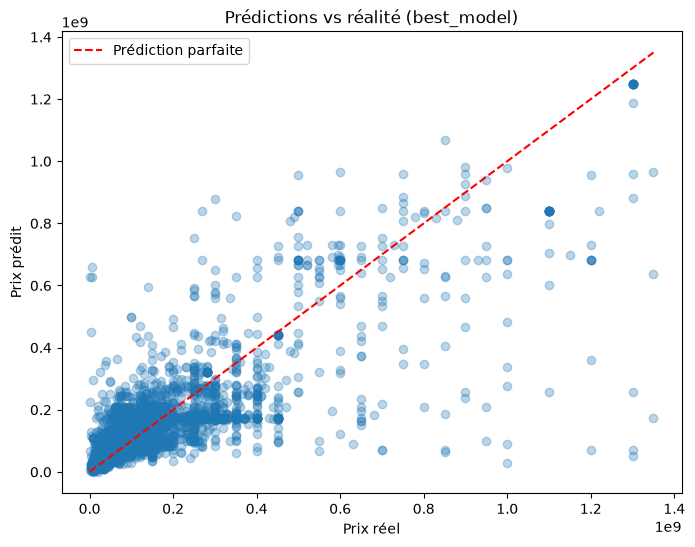

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_predict, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Prédiction parfaite")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prédictions vs réalité (best_model)")
plt.legend()
plt.show()

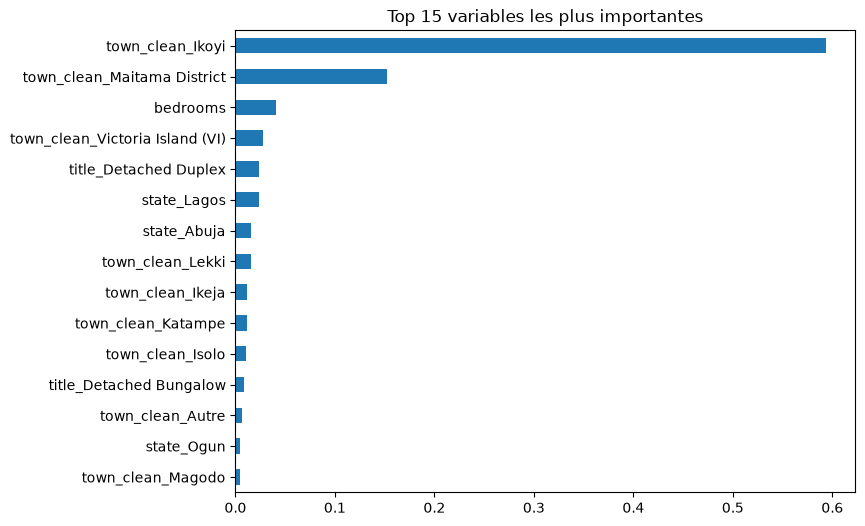

In [124]:
import pandas as pd

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 variables les plus importantes")
plt.gca().invert_yaxis()
plt.show()

In [125]:
erreurs = pd.DataFrame({
    'prix_reel': y_test,
    'prix_predit': y_predict,
    'erreur_abs': abs(y_test - y_predict)
})

erreurs['tranche'] = pd.qcut(erreurs['prix_reel'], q=4, labels=['Bas', 'Moyen-bas', 'Moyen-haut', 'Haut'])
erreurs.groupby('tranche')['erreur_abs'].mean()

tranche
Bas           2.893319e+07
Moyen-bas     3.243481e+07
Moyen-haut    4.694328e+07
Haut          1.228341e+08
Name: erreur_abs, dtype: float64

# Estimateur de prix immobilier — Nigeria

## Objectif
Prédire le prix d'un bien immobilier à partir de ses caractéristiques (chambres, salles de bain, toilettes, parking, ville, état, type de bien).

## Données
- Source : `nigeria_houses_data.csv` (24 326 annonces)
- Nettoyage : suppression des outliers au-delà du quantile 0.99 (326 lignes retirées)
- Regroupement des villes peu fréquentes en catégorie "Autre" (top 20 villes conservées)
- Encodage one-hot des variables catégorielles (town_clean, state, title) → 54 features

## Modèles testés

| Modèle | R² test | MAE test |
|---|---|---|
| Régression linéaire | 0,502 | 73,8M |
| Random Forest | 0,624 | 58,5M |
| Gradient Boosting | 0,644 | 57,9M |
| XGBoost (défaut) | 0,651 | 57,6M |
| **XGBoost + GridSearchCV** | **0,650** | **57,8M** |

## Modèle retenu
XGBoost avec les hyperparamètres optimisés par GridSearchCV (`learning_rate=0.05, max_depth=5, n_estimators=300`).

## Limites
- R² de 0,65 : environ 35% de la variance des prix reste inexpliquée par les variables disponibles
- Le modèle ne dispose pas de la surface exacte (`surface` était disponible via scraping mais pas dans le dataset final)
- Possibles pistes d'amélioration non explorées à fond : transformation log du prix, feature engineering plus poussé

In [127]:
import joblib

joblib.dump(best_model, 'estimateur_prix_xgboost.pkl')
print("Modèle sauvegardé.")

Modèle sauvegardé.


## Conclusion

Ce projet a permis de construire un pipeline complet de machine learning : collecte/chargement de données, nettoyage, feature engineering, comparaison de plusieurs modèles, et optimisation d'hyperparamètres.

Le modèle final (XGBoost) atteint un R² de 0,65 et une erreur moyenne d'environ 58M NGN, ce qui représente une nette amélioration par rapport à la régression linéaire de base (R²=0,50).

**Prochaines étapes possibles** : transformation logarithmique du prix, ajout de nouvelles features (ratios chambres/salles de bain), analyse plus fine des erreurs par segment de prix.